In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
start="2015-01-01"
end="2026-03-09"

In [3]:
symbol="GOOG"

In [4]:
df=yf.download(symbol,start,end,multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [5]:
df

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,25.955559,26.275053,25.920445,26.163278,28951268
2015-01-05,25.414499,25.931820,25.374440,25.878901,41196796
2015-01-06,24.825468,25.528501,24.780464,25.470389,57998800
2015-01-07,24.782936,25.086800,24.711223,25.074732,41301082
2015-01-08,24.861074,24.900640,24.283416,24.629121,67071641
...,...,...,...,...,...
2026-03-02,306.144318,307.923094,300.848061,302.751719,21854400
2026-03-03,303.346283,303.726020,296.490121,298.209918,20361100
2026-03-04,303.236389,305.244953,300.588230,302.471913,20015600


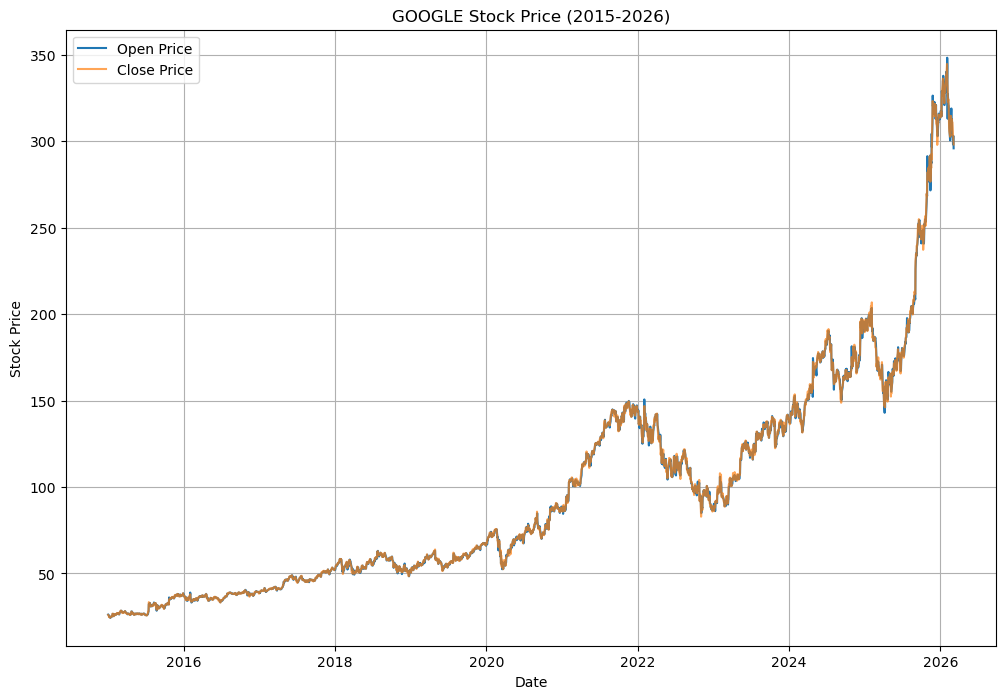

In [6]:
plt.figure(figsize=(12, 8))
plt.plot(df["Open"], label="Open Price")
plt.plot(df["Close"], label="Close Price",
alpha=0.7)
plt.title("GOOGLE Stock Price (2015-2026)")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()


In [7]:
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [8]:
df

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,25.955559,26.275053,25.920445,26.163278,28951268
2015-01-05,25.414499,25.931820,25.374440,25.878901,41196796
2015-01-06,24.825468,25.528501,24.780464,25.470389,57998800
2015-01-07,24.782936,25.086800,24.711223,25.074732,41301082
2015-01-08,24.861074,24.900640,24.283416,24.629121,67071641
...,...,...,...,...,...
2026-03-02,306.144318,307.923094,300.848061,302.751719,21854400
2026-03-03,303.346283,303.726020,296.490121,298.209918,20361100
2026-03-04,303.236389,305.244953,300.588230,302.471913,20015600


In [9]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_filtered = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [10]:
df

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,25.955559,26.275053,25.920445,26.163278,28951268
2015-01-05,25.414499,25.931820,25.374440,25.878901,41196796
2015-01-06,24.825468,25.528501,24.780464,25.470389,57998800
2015-01-07,24.782936,25.086800,24.711223,25.074732,41301082
2015-01-08,24.861074,24.900640,24.283416,24.629121,67071641
...,...,...,...,...,...
2026-03-02,306.144318,307.923094,300.848061,302.751719,21854400
2026-03-03,303.346283,303.726020,296.490121,298.209918,20361100
2026-03-04,303.236389,305.244953,300.588230,302.471913,20015600


In [11]:
from statsmodels.tsa.stattools import adfuller
# Test for stationarity
result = adfuller(df["Close"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
# If data is not stationary, apply differencing
if result[1] > 0.05:
    df["Close_Diff"] = df["Close"].diff()
    df.dropna(inplace=True)
    



ADF Statistic: 1.6892507503317782
p-value: 0.9981020949281498


In [12]:
df

,Close,High,Low,Open,Volume,Close_Diff
Date,,,,,,
2015-01-05,25.414499,25.931820,25.374440,25.878901,41196796,-0.541059
2015-01-06,24.825468,25.528501,24.780464,25.470389,57998800,-0.589031
2015-01-07,24.782936,25.086800,24.711223,25.074732,41301082,-0.042532
2015-01-08,24.861074,24.900640,24.283416,24.629121,67071641,0.078138
2015-01-09,24.539112,24.971860,24.470861,24.963948,41427428,-0.321962
...,...,...,...,...,...,...
2026-03-02,306.144318,307.923094,300.848061,302.751719,21854400,-5.066437
2026-03-03,303.346283,303.726020,296.490121,298.209918,20361100,-2.798035
2026-03-04,303.236389,305.244953,300.588230,302.471913,20015600,-0.109894


In [14]:
from statsmodels.tsa.arima.model import ARIMA

train = df[:int(len(df)*0.8)]
val = df[int(len(df)*0.8):]

model = ARIMA(train["Close_Diff"], order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(val))

c:\Users\rshaw\miniconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\rshaw\miniconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\rshaw\miniconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\rshaw\miniconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index begin

In [16]:
df["Price_Up"] = df["Close"].shift(-1) < df["Close"]
val["Price_Up"] = val["Close"].shift(-1) < val["Close"]

C:\Users\rshaw\AppData\Local\Temp\ipykernel_26484\1972859975.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val["Price_Up"] = val["Close"].shift(-1) < val["Close"]


In [18]:
df["Price_Up"]=df["Price_Up"].astype(int)

In [19]:
df

,Close,High,Low,Open,Volume,Close_Diff,Price_Up
Date,,,,,,,
2015-01-05,25.414499,25.931820,25.374440,25.878901,41196796,-0.541059,1
2015-01-06,24.825468,25.528501,24.780464,25.470389,57998800,-0.589031,1
2015-01-07,24.782936,25.086800,24.711223,25.074732,41301082,-0.042532,0
2015-01-08,24.861074,24.900640,24.283416,24.629121,67071641,0.078138,1
2015-01-09,24.539112,24.971860,24.470861,24.963948,41427428,-0.321962,1
...,...,...,...,...,...,...,...
2026-03-02,306.144318,307.923094,300.848061,302.751719,21854400,-5.066437,1
2026-03-03,303.346283,303.726020,296.490121,298.209918,20361100,-2.798035,1
2026-03-04,303.236389,305.244953,300.588230,302.471913,20015600,-0.109894,1


In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
# Extracting relevant columns
features = ["Open", "High", "Low", "Close", "Volume"]
X = df[features]
y = df["Price_Up"]
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)
# Training the model
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
# Predicting on the test set
y_pred = clf.predict(X_test)
# Evaluating the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5124555160142349
              precision    recall  f1-score   support

           0       0.57      0.54      0.56       316
           1       0.45      0.48      0.46       246

    accuracy                           0.51       562
   macro avg       0.51      0.51      0.51       562
weighted avg       0.52      0.51      0.51       562



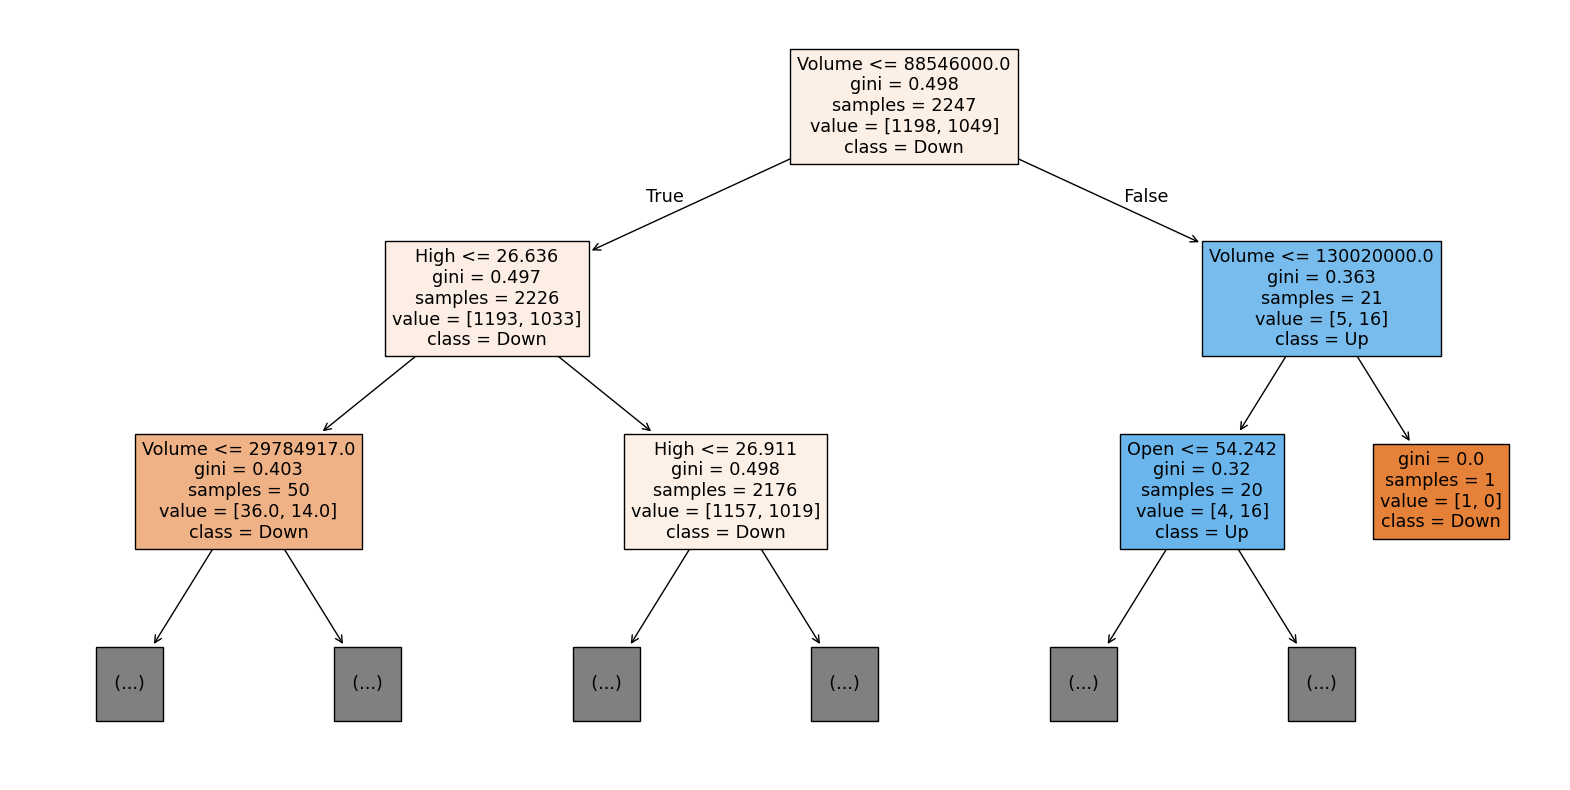

In [21]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
plot_tree(clf, filled=True, feature_names=features, class_names=
["Down", "Up"], max_depth=2)
plt.show()

In [22]:
from sklearn.model_selection import GridSearchCV
parameters = {
"max_depth": [3, 5, 7, 10],
"min_samples_split": [2, 5, 10],
"min_samples_leaf": [1, 2, 4]
}
grid_search = GridSearchCV(DecisionTreeClassifier(), parameters,
cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)
best_clf = grid_search.best_estimator_

In [23]:
# Using the model with best hyperparameters to predict on validation
set
y_val_pred = best_clf.predict(val[features])
# Creating the actual target for validation data
val["Price_Up"] = val["Close"].shift(-1) < val["Close"]
print("Validation Accuracy:", accuracy_score(val["Price_Up"], y_val_pred))
print(classification_report(val["Price_Up"], y_val_pred))

Validation Accuracy: 0.5587188612099644
              precision    recall  f1-score   support

       False       0.56      1.00      0.72       314
        True       0.00      0.00      0.00       248

    accuracy                           0.56       562
   macro avg       0.28      0.50      0.36       562
weighted avg       0.31      0.56      0.40       562



C:\Users\rshaw\AppData\Local\Temp\ipykernel_26484\1688979852.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val["Price_Up"] = val["Close"].shift(-1) < val["Close"]
c:\Users\rshaw\miniconda3\envs\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rshaw\miniconda3\envs\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 